# Verify GPU + Environment

In [1]:
!pip uninstall -y torch torchvision torchaudio

!pip install torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 \
--index-url https://download.pytorch.org/whl/cu121

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 109.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 92.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 74.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 36.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 93.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
#import os
# os._exit(0)

In [3]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

x = torch.rand(3,3).cuda()
print(x)

2.5.1+cu121
True
Tesla P100-PCIE-16GB
tensor([[0.1600, 0.0620, 0.9911],
        [0.3606, 0.6603, 0.7839],
        [0.8634, 0.6607, 0.6347]], device='cuda:0')


In [4]:
torch.backends.cudnn.benchmark = True

In [5]:
import torch
import os

print("=" * 60)
print("Environment Check")
print("=" * 60)

if torch.cuda.is_available():
    n_gpus = torch.cuda.device_count()
    print(f"✓ {n_gpus} GPU(s) detected:")
    for i in range(n_gpus):
        name = torch.cuda.get_device_name(i)
        vram = torch.cuda.get_device_properties(i).total_memory / 1024**3
        print(f"  [{i}] {name} — {vram:.1f} GB VRAM")
    
    if n_gpus > 1:
        print("\n⚠ WARNING: Multi-GPU detected!")
        print("  Recommend switching to single P100 in Settings panel.")
        print("  T4×2 will be 10-15× SLOWER for CycleGAN due to sync overhead.")
    elif 'P100' in torch.cuda.get_device_name(0):
        print("\n✓ P100 detected — optimal for CycleGAN training!")
    elif 'T4' in torch.cuda.get_device_name(0):
        print("\nℹ Single T4 detected — works fine, slightly slower than P100.")
else:
    raise RuntimeError("✗ No GPU detected — enable GPU in Settings panel")

print(f"\nPyTorch: {torch.__version__}")
print(f"CUDA: {torch.version.cuda}")

# Check internet (required for git clone and Roboflow)
print("\n--- Internet Check ---")
import urllib.request
try:
    urllib.request.urlopen('https://github.com', timeout=5)
    print("✓ Internet access available")
except Exception as e:
    print(f"✗ Internet access FAILED: {e}")
    print("  Enable in Settings panel → Internet toggle")
    print("  (Requires phone-verified Kaggle account)")

# Check working directory
print(f"\nWorking directory: {os.getcwd()}")
print(f"Free space in /kaggle/working: ", end='')
import shutil
total, used, free = shutil.disk_usage('/kaggle/working')
print(f"{free / 1024**3:.1f} GB free / {total / 1024**3:.1f} GB total")

Environment Check
✓ 1 GPU(s) detected:
  [0] Tesla P100-PCIE-16GB — 15.9 GB VRAM

✓ P100 detected — optimal for CycleGAN training!

PyTorch: 2.5.1+cu121
CUDA: 12.1

--- Internet Check ---
✓ Internet access available

Working directory: /kaggle/working
Free space in /kaggle/working: 19.5 GB free / 19.5 GB total


# Clone REPO

In [6]:
import os
import subprocess

# Clone into /kaggle/working/ (writable)
repo_path = '/kaggle/working/pytorch-CycleGAN-and-pix2pix'

if not os.path.exists(repo_path):
    subprocess.run([
        'git', 'clone',
        'https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix.git',
        repo_path
    ], check=True)
    print("✓ Repo cloned")
else:
    print("✓ Repo already exists")

# Verify key files
print("\nVerifying repo structure:")
for f in ['train.py', 'test.py', 'models/cycle_gan_model.py', 'datasets/combine_A_and_B.py']:
    path = f'{repo_path}/{f}'
    print(f"  {'✓' if os.path.exists(path) else '✗'} {f}")

Cloning into '/kaggle/working/pytorch-CycleGAN-and-pix2pix'...


✓ Repo cloned

Verifying repo structure:
  ✓ train.py
  ✓ test.py
  ✓ models/cycle_gan_model.py
  ✓ datasets/combine_A_and_B.py


# Install Dependencies

Kaggle pre-installs most packages. We just need `roboflow` for dataset download and `scikit-image` for SSIM.

In [7]:
!pip install -q roboflow scikit-image
print("✓ Dependencies installed")

# Verify
import roboflow
from skimage.metrics import structural_similarity
print(f"  roboflow: {roboflow.__version__}")
print("  scikit-image: SSIM ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 91.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.2.0 which is incompatible.
✓ Dependencies installed
  roboflow: 1.3.8
  scikit-image: SSIM ready


# Dataset

## Call Roboflow

In [8]:
from kaggle_secrets import UserSecretsClient
import os

try:
    user_secrets = UserSecretsClient()
    ROBOFLOW_API_KEY = user_secrets.get_secret("ROBOFLOW_API_KEY")
    print("✓ API key loaded from Kaggle Secrets")
except Exception as e:
    print("✗ ROBOFLOW_API_KEY not found in Kaggle Secrets")
    print(f"  Error: {e}")
    print("  See instructions in the markdown above")
    raise

✓ API key loaded from Kaggle Secrets


In [9]:
import roboflow
import os

DATASET_DOWNLOAD_DIR = '/kaggle/working/cyclegan-dataset'

# Skip download if already exists (save time on re-runs)
if os.path.exists(DATASET_DOWNLOAD_DIR) and os.listdir(DATASET_DOWNLOAD_DIR):
    print(f"✓ Dataset already downloaded at {DATASET_DOWNLOAD_DIR}")
    print("  (skipping download)")
else:
    rf = roboflow.Roboflow(api_key=ROBOFLOW_API_KEY)
    project = rf.workspace("datasetta-ubg4x").project("traintestrgbndvi-ilx7x")
    version = project.version(1)
    dataset = version.download("folder", location=DATASET_DOWNLOAD_DIR)
    print(f"\n✓ Dataset downloaded to {DATASET_DOWNLOAD_DIR}")

# Verify download structure
print("\nDataset structure:")
for root, dirs, files in os.walk(DATASET_DOWNLOAD_DIR):
    level = root.replace(DATASET_DOWNLOAD_DIR, '').count(os.sep)
    if level <= 2:
        indent = '  ' * level
        n_files = len([f for f in files if not f.startswith('.')])
        marker = f" ({n_files} files)" if n_files else ""
        print(f"{indent}{os.path.basename(root) or DATASET_DOWNLOAD_DIR}/{marker}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /kaggle/working/cyclegan-dataset in folder:: 100%|██████████| 608/608 [00:00<00:00, 3603.87it/s]


✓ Dataset downloaded to /kaggle/working/cyclegan-dataset

Dataset structure:
cyclegan-dataset/ (2 files)
  train/
    rgb/ (150 files)
    ndvi/ (150 files)
  test/
    rgb/ (150 files)
    ndvi/ (150 files)


## Split Data and Organize for CycleGAN

* 80/20 train/test split with `random_state=2024` (same as Pix2Pix → fair comparison)
* CycleGAN structure: `trainA/`, `trainB/`, `testA/`, `testB/` (flat folders, NOT nested A/B/train/test)
* Filenames renamed to sequential `001.jpg`, `002.jpg`, ... for clean organization

In [10]:
import os
from sklearn.model_selection import train_test_split
from shutil import copyfile

# Source paths (Roboflow downloads into a /train/ subfolder by default)
raw_train_root = os.path.join(DATASET_DOWNLOAD_DIR, 'train')
rgb_path = os.path.join(raw_train_root, 'rgb')
ndvi_path = os.path.join(raw_train_root, 'ndvi')

if not os.path.exists(rgb_path) or not os.path.exists(ndvi_path):
    print(f"✗ Expected folders not found.")
    print(f"  Looking for: {rgb_path}")
    print(f"  Looking for: {ndvi_path}")
    print(f"\nActual download contents:")
    for item in os.listdir(DATASET_DOWNLOAD_DIR):
        print(f"  {item}")
    raise FileNotFoundError("Dataset structure unexpected — check Roboflow download")

# Destination (CycleGAN structure inside the repo)
CYCLEGAN_DATASET_DIR = '/kaggle/working/pytorch-CycleGAN-and-pix2pix/datasets/datasetta-ubg4x-cyclegan'
for folder in ['trainA', 'trainB', 'testA', 'testB']:
    os.makedirs(os.path.join(CYCLEGAN_DATASET_DIR, folder), exist_ok=True)

# Get and sort files (sorting ensures consistent split across runs)
rgb_files = sorted([f for f in os.listdir(rgb_path) if f.endswith('.jpg')])
ndvi_files = sorted([f for f in os.listdir(ndvi_path) if f.endswith('.jpg')])

print(f"Source counts: {len(rgb_files)} RGB, {len(ndvi_files)} NDVI")
assert len(rgb_files) == len(ndvi_files), "RGB and NDVI counts must match!"

# Same split as pix2pix (random_state=2024)
indices = list(range(len(rgb_files)))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=2024)

# Copy training files
for i in train_idx:
    copyfile(os.path.join(rgb_path, rgb_files[i]),
             os.path.join(CYCLEGAN_DATASET_DIR, 'trainA', rgb_files[i]))
    copyfile(os.path.join(ndvi_path, ndvi_files[i]),
             os.path.join(CYCLEGAN_DATASET_DIR, 'trainB', ndvi_files[i]))

# Copy test files
for i in test_idx:
    copyfile(os.path.join(rgb_path, rgb_files[i]),
             os.path.join(CYCLEGAN_DATASET_DIR, 'testA', rgb_files[i]))
    copyfile(os.path.join(ndvi_path, ndvi_files[i]),
             os.path.join(CYCLEGAN_DATASET_DIR, 'testB', ndvi_files[i]))

# Rename to sequential numbering for clean organization
def rename_to_sequential(folder_path):
    files = sorted(os.listdir(folder_path))
    for idx, old_name in enumerate(files, start=1):
        os.rename(
            os.path.join(folder_path, old_name),
            os.path.join(folder_path, f"{idx:03d}.jpg")
        )

for folder in ['trainA', 'trainB', 'testA', 'testB']:
    rename_to_sequential(os.path.join(CYCLEGAN_DATASET_DIR, folder))

print("\n✓ Dataset organized for CycleGAN:")
for folder in ['trainA', 'trainB', 'testA', 'testB']:
    path = os.path.join(CYCLEGAN_DATASET_DIR, folder)
    print(f"  {folder}/  ({len(os.listdir(path))} files)")

Source counts: 150 RGB, 150 NDVI

✓ Dataset organized for CycleGAN:
  trainA/  (120 files)
  trainB/  (120 files)
  testA/  (30 files)
  testB/  (30 files)


## Visual Sanity Check

train: ✓ filenames match
test: ✓ filenames match


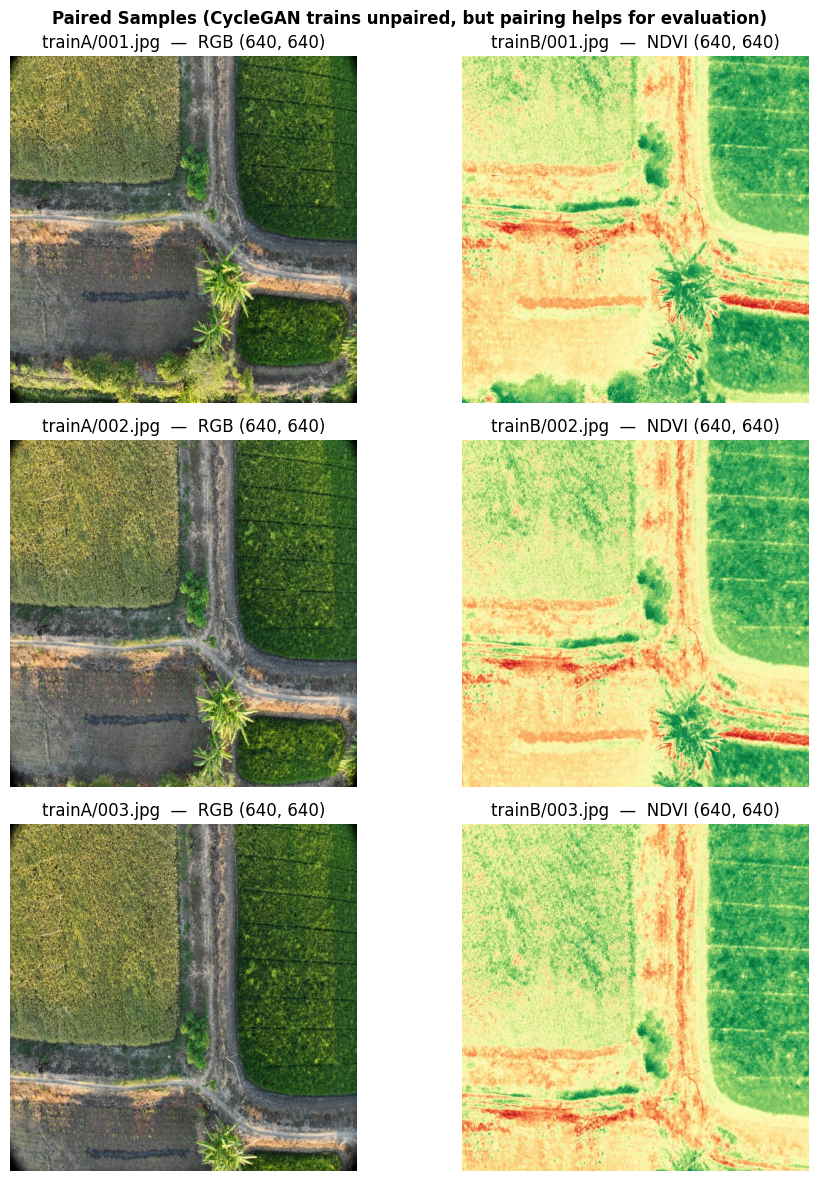

In [11]:
import os
from PIL import Image
import matplotlib.pyplot as plt

base = '/kaggle/working/pytorch-CycleGAN-and-pix2pix/datasets/datasetta-ubg4x-cyclegan'

# Verify filename matching
for split in ['train', 'test']:
    a_files = sorted(os.listdir(os.path.join(base, f'{split}A')))
    b_files = sorted(os.listdir(os.path.join(base, f'{split}B')))
    match = a_files == b_files
    print(f"{split}: {'✓' if match else '✗'} filenames {'match' if match else 'DIFFER'}")

# Visualize 3 paired samples
fig, axes = plt.subplots(3, 2, figsize=(10, 12))
sample_files = sorted(os.listdir(os.path.join(base, 'trainA')))[:3]

for row, fname in enumerate(sample_files):
    img_a = Image.open(os.path.join(base, 'trainA', fname))
    img_b = Image.open(os.path.join(base, 'trainB', fname))
    axes[row, 0].imshow(img_a)
    axes[row, 0].set_title(f"trainA/{fname}  —  RGB {img_a.size}")
    axes[row, 0].axis('off')
    axes[row, 1].imshow(img_b)
    axes[row, 1].set_title(f"trainB/{fname}  —  NDVI {img_b.size}")
    axes[row, 1].axis('off')

plt.suptitle('Paired Samples (CycleGAN trains unpaired, but pairing helps for evaluation)', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Traning

In [12]:
!pip install -q dominate visdom

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [13]:
import dominate
import visdom

print("✓ dominate OK")
print("✓ visdom OK")

✓ dominate OK
✓ visdom OK


In [14]:

import os
os.chdir('/kaggle/working/pytorch-CycleGAN-and-pix2pix')

!python train.py \
    --dataroot ./datasets/datasetta-ubg4x-cyclegan \
    --name rgb2ndvi_cyclegan \
    --model cycle_gan \
    --dataset_mode unaligned \
    --netG resnet_9blocks \
    --norm instance \
    --no_dropout \
    --batch_size 1 \
    --load_size 286 \
    --crop_size 256 \
    --preprocess resize_and_crop \
    --n_epochs 50 \
    --n_epochs_decay 50 \
    --lambda_A 10.0 \
    --lambda_B 10.0 \
    --lambda_identity 0.5 \
    --save_epoch_freq 5 \
    --save_latest_freq 500 \
    --print_freq 30 \
    --display_freq 100 \
    # --gpu_ids 0 \
    2>&1 | tee /kaggle/working/training_log.txt

----------------- Options ---------------
               batch_size: 1                             
                    beta1: 0.5                           
          checkpoints_dir: ./checkpoints                 
           continue_train: False                         
                crop_size: 256                           
                 dataroot: ./datasets/datasetta-ubg4x-cyclegan	[default: None]
             dataset_mode: unaligned                     
                direction: AtoB                          
             display_freq: 100                           	[default: 400]
          display_winsize: 256                           
                    epoch: latest                        
              epoch_count: 1                             
                 gan_mode: lsgan                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                        

## Save (.zip) checkpoint

In [15]:
import os
import zipfile
from datetime import datetime

print("=" * 60)
print("CYCLEGAN BACKUP")
print("=" * 60)

# Save outputs to /kaggle/working/ so they persist after commit
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
backup_zip = f'/kaggle/working/cyclegan_rice_ndvi_{timestamp}.zip'

repo_path = '/kaggle/working/pytorch-CycleGAN-and-pix2pix'

print(f"\nCreating zip: {backup_zip}")
print("(This may take 2-5 minutes for ~4GB)")

with zipfile.ZipFile(backup_zip, 'w', zipfile.ZIP_DEFLATED, compresslevel=6) as zipf:
    for root, dirs, files in os.walk(repo_path):
        # Skip git and cache
        dirs[:] = [d for d in dirs if d not in ('.git', '__pycache__')]
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, '/kaggle/working')
            zipf.write(file_path, arcname)

zip_size_gb = os.path.getsize(backup_zip) / (1024**3)
print(f"\n✓ Backup created: {zip_size_gb:.2f} GB")
print(f"  Location: {backup_zip}")

# Also write a summary file
info_path = '/kaggle/working/SESSION_INFO.txt'
with open(info_path, 'w') as f:
    f.write(f"CycleGAN RGB→NDVI Training Session (Kaggle)\n")
    f.write("=" * 50 + "\n\n")
    f.write(f"Created: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Platform: Kaggle (P100 GPU)\n")
    f.write(f"Model: CycleGAN (cycle_gan)\n")
    f.write(f"Architecture: resnet_9blocks generator + basic PatchGAN discriminator\n")
    f.write(f"Training: 100 epochs (50 constant + 50 decay), batch_size=1\n")
    f.write(f"Resolution: 256×256 (resized from 286×286 with random crop)\n")
    f.write(f"Lambdas: A=10.0, B=10.0, identity=0.5\n")
    f.write(f"Dataset: Roboflow traintestrgbndvi, split with random_state=2024\n")
    f.write(f"Same split as companion Pix2Pix run for direct comparison\n")

print("\n✓ Session info written")

CYCLEGAN BACKUP

Creating zip: /kaggle/working/cyclegan_rice_ndvi_20260511_182419.zip
(This may take 2-5 minutes for ~4GB)

✓ Backup created: 2.20 GB
  Location: /kaggle/working/cyclegan_rice_ndvi_20260511_182419.zip

✓ Session info written
